# Flood Monitoring: Merged Text + Image Pipeline

This notebook merges `flood_monitoring_twitter_text.ipynb` and `flood_monitoring_twitter_image.ipynb` into a single run.

Both notebooks fine-tune a separate model (RoBERTa on tweet text, InceptionV4 on tweet images) for the same 3-class flood-severity task (Mild / Moderate / Severe), and both were going to feed a downstream GNN keyed by post. Running them independently meant each picked its own train/val/test split, so a post could end up in the text model's *train* set and the image model's *test* set, which would leak information once the GNN joins the two.

This notebook fixes that by building **one post-level train/val/test split** up front, driven by the (more complete) text-severity labels, and having both the text and image pipelines filter down to that same split. Every post keeps its `tweet_id` end to end (kept as the field name for continuity with the original notebooks, though it now identifies posts from more than one platform, as described below), and a manifest cell writes a mapping from each `tweet_id` → split → which modalities are available for it, ready for GNN graph construction.

It also folds in a second, Facebook-sourced dataset (`typhoons_annotated.csv`), now with both text and images:

- Facebook `postId`s and Twitter `tweet_id`s are different ID spaces, so every ID is prefixed by platform (`tw_...` / `fb_...`) before the two are combined. This keeps them from colliding and lets the shared split and manifest tell them apart.
- About 4.7% of `typhoons_annotated.csv` rows have a `postId` corrupted into scientific notation (e.g. `1.18E+15`), almost certainly from the file having passed through Excel/Sheets at some point. Distinct posts collapse onto the same corrupted ID, so those rows are dropped rather than risk merging unrelated posts.
- The Facebook `attachments/*/url` fields are page permalinks (`facebook.com/photo.php?...`), not direct image files, but `facebook-typhoon-images.zip` contains the actual downloaded photos, named by each attachment's own `attachments/N/id` (not the post's `postId`), so Facebook images are matched on that ID instead of `tweet_id`.
- `typhoons_all.csv` (the larger, unannotated raw scrape typhoons_annotated.csv was labeled from) is intentionally not loaded here. It's being held aside as a pool of unlabeled nodes for the GNN step.

## 1. Set Up Colab Environment
*GPU runtime: Runtime → Change runtime type → T4 GPU*

In [ ]:
!pip install transformers datasets scikit-learn pandas torch timm torchvision pillow

## 2. Upload Data

Upload everything in one go: the text-annotated CSVs (`*-annotated.csv`), the image-annotated CSVs (`*-image-annotated.csv`), the Twitter image zip archives (`*-images.zip`), `typhoons_annotated.csv`, `facebook-typhoon-images.zip`, and `socialcrawl_annotated.csv`. Files are written to `/content` so both the CSV loaders and the zip extractor can find them.

(`typhoons_all.csv` doesn't need to be uploaded here, it's unused until the GNN notebook.)

In [ ]:
from google.colab import files
import os

uploaded = files.upload()
for filename, content in uploaded.items():
    with open(os.path.join('/content', filename), 'wb') as f:
        f.write(content)

print(f"Uploaded {len(uploaded)} files to /content")

Saving socialcrawl_annotated.csv to socialcrawl_annotated.csv
Saving typhoons_annotated.csv to typhoons_annotated.csv
Uploaded 2 files to /content


In [ ]:
import glob

all_csv = glob.glob('/content/*.csv')
zip_files = glob.glob('/content/*.zip')

# Image-annotated CSVs are named "<event>-image-annotated.csv"; text CSVs are "<event>-annotated.csv".
# typhoons_annotated.csv / typhoons_all.csv are handled separately (different schema, Facebook source).
# socialcrawl_*.csv is handled separately too (different schema, loaded and labeled in its own section).
text_csv_files  = [f for f in all_csv
                    if 'image' not in os.path.basename(f).lower()
                    and not os.path.basename(f).lower().startswith('typhoons')
                    and not os.path.basename(f).lower().startswith('socialcrawl')]
image_csv_files = [f for f in all_csv if 'image' in os.path.basename(f).lower()]

print(f"Text CSVs: {len(text_csv_files)}")
for f in text_csv_files:
    print(" -", os.path.basename(f))

print(f"\nImage CSVs: {len(image_csv_files)}")
for f in image_csv_files:
    print(" -", os.path.basename(f))

print(f"\nZip archives: {len(zip_files)}")
for f in zip_files:
    print(" -", os.path.basename(f))

Text CSVs: 17
 - ulysis-annotated.csv
 - monsoon-annotated.csv
 - jolina-annotated.csv
 - rolly-annotated.csv
 - kristine-annotated.csv
 - paeng-annotated.csv
 - karding-annotated.csv
 - fabian-annotated.csv
 - egay-annotated.csv
 - pepito-annotated.csv
 - maring-annotated.csv
 - qc_marikina-annotated.csv
 - quinta-annotated.csv
 - ondoy-annotated.csv
 - enteng-annotated.csv
 - leon-annotated.csv
 - carina-annotated.csv

Image CSVs: 16
 - monsoon-image-annotated.csv
 - ondoy-image-annotated.csv
 - qc_marikina-image-annotated.csv
 - paeng-image-annotated.csv
 - leon-image-annotated.csv
 - maring-image-annotated.csv
 - carina-image-annotated.csv
 - rolly-image-annotated.csv
 - pepito-image-annotated.csv
 - fabian-image-annotated.csv
 - kristine-image-annotated.csv
 - enteng-image-annotated.csv
 - egay-image-annotated.csv
 - quinta-image-annotated.csv
 - jolina-image-annotated.csv
 - karding-image-annotated.csv

Zip archives: 17
 - facebook-typhoon-images.zip
 - pepito-images.zip
 - paeng

## 3. Common Setup

Shared across both pipelines: device, random seed, and a single `severity_encoder` so the text and image models use the *identical* Mild/Moderate/Severe → index mapping (previously each notebook fit its own `LabelEncoder`, which happened to agree but wasn't guaranteed to).

In [ ]:
import numpy as np
import pandas as pd
import re
import torch
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

RANDOM_STATE = 42
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

severity_encoder = LabelEncoder().fit(['Mild', 'Moderate', 'Severe'])
print("Shared label encoding:", dict(zip(severity_encoder.classes_, severity_encoder.transform(severity_encoder.classes_))))

def extract_tweet_id(url):
    """Pull the numeric tweet ID out of a x.com/.../status/<id> URL, prefixed for cross-platform uniqueness."""
    match = re.search(r'/status/(\d+)', str(url))
    return f'tw_{match.group(1)}' if match else None

Shared label encoding: {np.str_('Mild'): np.int64(0), np.str_('Moderate'): np.int64(1), np.str_('Severe'): np.int64(2)}


## 4. Load and Clean Twitter Text Data

Same cleanup as the original text notebook, plus: keep the `url` column so we can derive `tweet_id`, and explicitly map raw severity labels to the 3 canonical classes (dropping `Not Relevant` / `Text Only` and fixing the `Moderatet` typo) instead of relying on the labels already being clean.

In [ ]:
text_dfs = []
for csv_path in text_csv_files:
    filename = os.path.basename(csv_path)
    temp_df = pd.read_csv(csv_path)
    temp_df.columns = temp_df.columns.str.strip()
    temp_df['source_file'] = filename

    label_col = None
    for col in temp_df.columns:
        if col.lower() == 'severity level':
            label_col = col
            break
    if label_col is None:
        print(f"WARNING: No severity column found in {filename}, skipping")
        continue

    temp_df = temp_df.rename(columns={label_col: 'label'})
    text_dfs.append(temp_df)

text_df = pd.concat(text_dfs, ignore_index=True)
text_df = text_df.loc[:, ~text_df.columns.str.startswith('Unnamed')]
text_df = text_df[['url', 'text', 'label', 'source_file', 'createdAt', 'likeCount', 'retweetCount']].copy()
text_df['platform'] = 'twitter'

print(f"Total text rows loaded: {len(text_df)}")

Total text rows loaded: 4631


In [ ]:
TEXT_LABEL_MAP = {
    'MILD': 'Mild',
    'MODERATE': 'Moderate',
    'MODERATET': 'Moderate',  # typo seen in raw annotations
    'SEVERE': 'Severe',
    'NOT RELEVANT': None,
    'TEXT ONLY': None,
}

text_df['tweet_id'] = text_df['url'].apply(extract_tweet_id)
text_df['label'] = text_df['label'].astype(str).str.strip().str.upper().map(TEXT_LABEL_MAP)

text_df = text_df.dropna(subset=['text', 'label', 'tweet_id'])
text_df = text_df.drop_duplicates(subset=['tweet_id'])

print(f"Text rows after cleaning: {len(text_df)}")
print(f"\nClass distribution:\n{text_df['label'].value_counts()}")

Text rows after cleaning: 415

Class distribution:
label
Mild        212
Severe      142
Moderate     61
Name: count, dtype: int64


## 5. Load and Clean Facebook Text Data

Loads `typhoons_annotated.csv` (Facebook posts from 18 typhoon events, text and image labels annotated together in the same file). Only the text side is handled in this section; the image side (`facebook-typhoon-images.zip`) is cleaned and matched later, in the section right after the Twitter image matching step.

- `postId` is the unique identifier (Facebook permalinks don't embed a clean numeric ID the way `/status/<id>` does on Twitter, and often use opaque `pfbid...` tokens instead).
- Rows where `postId` looks like scientific notation (corrupted precision) are dropped, since distinct posts collapse onto the same string and can't be safely deduped or joined.
- `text_annotated_flood_severity` values (`irrelevant` / `mild` / `moderate` / `severe`) are mapped the same way as the Twitter labels, dropping `irrelevant`.

In [ ]:
FB_TEXT_LABEL_MAP = {
    'IRRELEVANT': None,
    'MILD': 'Mild',
    'MODERATE': 'Moderate',
    'SEVERE': 'Severe',
}

# dtype=str on postId and the attachment ID columns avoids pandas silently inferring a numeric
# dtype, which would reformat every value (including the clean ones) through a float round-trip
# and break both the postId corruption check below and the image-attachment matching later on.
attachment_id_dtypes = {f'attachments/{i}/id': str for i in range(5)}
fb_df = pd.read_csv('/content/typhoons_annotated.csv', dtype={'postId': str, **attachment_id_dtypes})
print(f"Facebook rows loaded: {len(fb_df)}")

# Drop postIds corrupted into scientific notation (e.g. "1.18E+15") before dedup/joining
looks_like_plain_int = fb_df['postId'].str.match(r'^\d+$')
n_corrupted = (~looks_like_plain_int).sum()
fb_df = fb_df[looks_like_plain_int].copy()
fb_df = fb_df.drop_duplicates(subset=['postId'])
print(f"Dropped {n_corrupted} rows with a corrupted postId; {len(fb_df)} remain after dedup")

fb_df['tweet_id'] = 'fb_' + fb_df['postId'].astype(str)
fb_df['label'] = fb_df['text_annotated_flood_severity'].astype(str).str.strip().str.upper().map(FB_TEXT_LABEL_MAP)
fb_df['text'] = fb_df['postText']
fb_df['source_file'] = 'typhoons_annotated.csv'
fb_df['createdAt'] = pd.to_datetime(fb_df['timestamp'], unit='ms', errors='coerce')
fb_df['likeCount'] = pd.to_numeric(fb_df['reactions/like'], errors='coerce')
fb_df['retweetCount'] = pd.to_numeric(fb_df['sharesCount'], errors='coerce')  # closest Facebook analog to a retweet
fb_df['platform'] = 'facebook'

fb_text_df = fb_df[['url', 'text', 'label', 'source_file', 'createdAt', 'likeCount', 'retweetCount', 'tweet_id', 'platform']].copy()
fb_text_df = fb_text_df.dropna(subset=['label', 'tweet_id'])
fb_text_df = fb_text_df[fb_text_df['text'].notna() & (fb_text_df['text'].str.strip() != '')]

print(f"\nFacebook text rows after cleaning: {len(fb_text_df)}")
print(f"\nClass distribution:\n{fb_text_df['label'].value_counts()}")

Facebook rows loaded: 8044
Dropped 375 rows with a corrupted postId; 7669 remain after dedup

Facebook text rows after cleaning: 4278

Class distribution:
label
Mild        2439
Moderate    1171
Severe       668
Name: count, dtype: int64


## 6. Load and Clean SocialCrawl Text Data

Loads `socialcrawl_annotated.csv`, a second, broader Twitter/X dataset (2009-2026, 914 posts) collected separately and already annotated Mild/Moderate/Severe/Not Relevant. It uses the same platform and the same tweet ID scheme as `/status/<id>` URLs, so prefixing it with `tw_` the same way lets duplicate tweets across the two Twitter sources get caught by the dedup step below rather than double-counted.

In [ ]:
# dtype=str on id for the same reason as postId earlier: large tweet IDs would otherwise be
# silently reformatted through a float round-trip by pandas' type inference.
socialcrawl_df = pd.read_csv('/content/socialcrawl_annotated.csv', dtype={'id': str})
print(f"SocialCrawl rows loaded: {len(socialcrawl_df)}")

socialcrawl_df['tweet_id'] = 'tw_' + socialcrawl_df['id'].astype(str)
socialcrawl_df['label'] = socialcrawl_df['severity_label']
socialcrawl_df['source_file'] = 'socialcrawl_annotated.csv'
socialcrawl_df['platform'] = 'twitter'
socialcrawl_df['createdAt'] = socialcrawl_df['created_at']
socialcrawl_df['likeCount'] = pd.to_numeric(socialcrawl_df['likes'], errors='coerce')
socialcrawl_df['retweetCount'] = pd.to_numeric(socialcrawl_df['shares'], errors='coerce')

socialcrawl_text_df = socialcrawl_df[['url', 'text', 'label', 'source_file', 'createdAt', 'likeCount', 'retweetCount', 'tweet_id', 'platform']].copy()
socialcrawl_text_df = socialcrawl_text_df.dropna(subset=['text', 'label', 'tweet_id'])
socialcrawl_text_df = socialcrawl_text_df[socialcrawl_text_df['label'] != 'Not Relevant']

print(f"SocialCrawl text rows after cleaning (labeled, relevant only): {len(socialcrawl_text_df)}")
print(f"\nClass distribution:\n{socialcrawl_text_df['label'].value_counts()}")

SocialCrawl rows loaded: 914
SocialCrawl text rows after cleaning (labeled, relevant only): 306

Class distribution:
label
Mild        156
Moderate    117
Severe       33
Name: count, dtype: int64


## 7. Combine Text Sources

In [ ]:
text_df = pd.concat([text_df, fb_text_df, socialcrawl_text_df], ignore_index=True)
text_df = text_df.drop_duplicates(subset=['tweet_id'])

print(f"Combined text rows: {len(text_df)}")
print(f"\nBy platform:\n{text_df['platform'].value_counts()}")
print(f"\nCombined class distribution:\n{text_df['label'].value_counts()}")

Combined text rows: 4997

By platform:
platform
facebook    4278
twitter      719
Name: count, dtype: int64

Combined class distribution:
label
Mild        2807
Moderate    1349
Severe       841
Name: count, dtype: int64


## 8. Load and Clean Image Metadata

Same as the original image notebook's label/ID extraction, applied to `image_csv_files` (Twitter only).

In [ ]:
img_dfs = []
for csv_path in image_csv_files:
    temp_df = pd.read_csv(csv_path)
    temp_df['csv_source'] = os.path.basename(csv_path)
    img_dfs.append(temp_df)

image_df = pd.concat(img_dfs, ignore_index=True)
print(f"Total image-metadata rows loaded: {len(image_df)}")

image_df['tweet_id'] = image_df['url'].apply(extract_tweet_id)

IMAGE_LABEL_MAP = {
    'MILD': 'Mild',
    'MODERATE': 'Moderate',
    'SEVERE': 'Severe',
    'NOT RELEVANT': None,
}
image_df['label'] = image_df['imageSeverity'].astype(str).str.strip().str.upper().map(IMAGE_LABEL_MAP)
image_df = image_df.dropna(subset=['label', 'tweet_id'])

print(f"Image-metadata rows after cleaning: {len(image_df)}")
print(image_df['label'].value_counts())

Total image-metadata rows loaded: 2128
Image-metadata rows after cleaning: 149
label
Mild        71
Severe      41
Moderate    37
Name: count, dtype: int64


## 9. Extract Images and Match to Tweets

In [ ]:
import zipfile

extract_root = '/content/flood_images'
os.makedirs(extract_root, exist_ok=True)

good_zips, bad_zips = [], []
for zip_path in zip_files:
    try:
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.testzip()
        good_zips.append(zip_path)
    except zipfile.BadZipFile:
        bad_zips.append(zip_path)

print(f"Good zips: {len(good_zips)}")
for z in good_zips:
    print(" -", os.path.basename(z))

if bad_zips:
    print(f"\nCorrupted zips (skipped): {len(bad_zips)}")
    for z in bad_zips:
        print(" -", os.path.basename(z))

for zip_path in good_zips:
    folder_name = os.path.splitext(os.path.basename(zip_path))[0]
    extract_path = os.path.join(extract_root, folder_name)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(f"Extracted {os.path.basename(zip_path)} -> {extract_path}")

Good zips: 17
 - facebook-typhoon-images.zip
 - pepito-images.zip
 - paeng-images.zip
 - rolly-images.zip
 - carina-images.zip
 - jolina-images.zip
 - quinta-images.zip
 - kristine-images.zip
 - ondoy-images.zip
 - karding-images.zip
 - egay-images.zip
 - maring-images.zip
 - qc_marikina-images.zip
 - enteng-images.zip
 - fabian-images.zip
 - leon-images.zip
 - monsoon-images.zip
Extracted facebook-typhoon-images.zip -> /content/flood_images/facebook-typhoon-images
Extracted pepito-images.zip -> /content/flood_images/pepito-images
Extracted paeng-images.zip -> /content/flood_images/paeng-images
Extracted rolly-images.zip -> /content/flood_images/rolly-images
Extracted carina-images.zip -> /content/flood_images/carina-images
Extracted jolina-images.zip -> /content/flood_images/jolina-images
Extracted quinta-images.zip -> /content/flood_images/quinta-images
Extracted kristine-images.zip -> /content/flood_images/kristine-images
Extracted ondoy-images.zip -> /content/flood_images/ondoy-ima

In [ ]:
# Match each labeled tweet to its image file(s), excluding videos
VALID_EXTENSIONS = ('.jpg', '.jpeg', '.png')

def find_images_for_id(tweet_id, search_root):
    # Image filenames in the zips use the raw numeric tweet ID, not the tw_-prefixed
    # version used elsewhere in this notebook for cross-platform uniqueness.
    raw_id = tweet_id.split('_', 1)[1] if tweet_id.startswith('tw_') else tweet_id
    pattern = os.path.join(search_root, '**', f'{raw_id}_*.*')
    all_matches = glob.glob(pattern, recursive=True)
    return [f for f in all_matches if f.lower().endswith(VALID_EXTENSIONS)]

expanded_rows = []
for idx, row in image_df.iterrows():
    matched_files = find_images_for_id(row['tweet_id'], extract_root)
    for filepath in matched_files:
        expanded_rows.append({
            'tweet_id': row['tweet_id'],
            'full_path': filepath,
            'label': row['label'],
            'csv_source': row['csv_source']
        })

image_label_df = pd.DataFrame(expanded_rows, columns=['tweet_id', 'full_path', 'label', 'csv_source'])

print(f"Total images matched: {len(image_label_df)}")
print(f"Tweets with at least 1 image found: {image_label_df['tweet_id'].nunique()} / {image_df['tweet_id'].nunique()}")
if len(image_label_df):
    print(f"\nLabel distribution at IMAGE level:\n{image_label_df['label'].value_counts()}")

Total images matched: 407
Tweets with at least 1 image found: 149 / 149

Label distribution at IMAGE level:
label
Mild        201
Severe      103
Moderate    103
Name: count, dtype: int64


## 10. Load, Clean, and Match Facebook Images

`facebook-typhoon-images.zip` (already extracted by the cell above, since it loops over every zip in `/content`) contains the actual downloaded photos for the Facebook posts. Unlike Twitter, where files are named by `tweet_id`, these are named by the photo's own `attachments/N/id`. A post can have up to 5 attachment slots, and only the ones with `type == 'photo'` are images (the rest are videos or empty). Matching therefore keys off attachment ID, not `tweet_id`.

In [ ]:
FB_IMAGE_LABEL_MAP = {
    'MILD': 'Mild',
    'MODERATE': 'Moderate',
    'SEVERE': 'Severe',
    'IRRELEVANT': None,
    'NO IMAGE': None,
}

fb_df['image_label'] = fb_df['image_annotated_flood_severity'].astype(str).str.strip().str.upper().map(FB_IMAGE_LABEL_MAP)

def photo_attachment_ids(row):
    ids = []
    for i in range(5):
        if row.get(f'attachments/{i}/type') == 'photo':
            att_id = row.get(f'attachments/{i}/id')
            if pd.notna(att_id) and str(att_id).strip():
                ids.append(str(att_id).strip())
    return ids

fb_df['photo_attachment_ids'] = fb_df.apply(photo_attachment_ids, axis=1)

fb_image_df = (fb_df[fb_df['image_label'].notna() & (fb_df['photo_attachment_ids'].str.len() > 0)]
               [['tweet_id', 'image_label', 'photo_attachment_ids']]
               .rename(columns={'image_label': 'label'})
               .copy())
fb_image_df['csv_source'] = 'typhoons_annotated.csv'

print(f"Facebook posts with a valid image label and at least one photo attachment: {len(fb_image_df)}")
print(fb_image_df['label'].value_counts())

Facebook posts with a valid image label and at least one photo attachment: 932
label
Mild        379
Moderate    364
Severe      189
Name: count, dtype: int64


In [ ]:
# Facebook image files are named by the photo's own attachment ID (attachments/N/id), not tweet_id
def find_images_for_attachment(attachment_id, search_root):
    pattern = os.path.join(search_root, '**', f'{attachment_id}*.*')
    all_matches = glob.glob(pattern, recursive=True)
    return [f for f in all_matches if f.lower().endswith(VALID_EXTENSIONS)]

fb_expanded_rows = []
for idx, row in fb_image_df.iterrows():
    for att_id in row['photo_attachment_ids']:
        matched_files = find_images_for_attachment(att_id, extract_root)
        for filepath in matched_files:
            fb_expanded_rows.append({
                'tweet_id': row['tweet_id'],
                'full_path': filepath,
                'label': row['label'],
                'csv_source': row['csv_source']
            })

fb_image_label_df = pd.DataFrame(fb_expanded_rows, columns=['tweet_id', 'full_path', 'label', 'csv_source'])
print(f"Facebook images matched: {len(fb_image_label_df)}")
print(f"Facebook posts with at least 1 image found: {fb_image_label_df['tweet_id'].nunique()} / {fb_image_df['tweet_id'].nunique()}")

# Fold Facebook images into the same combined frames the Twitter pipeline already built,
# so everything downstream (shared split, manifest, dataloaders) sees one unified pool
image_label_df = pd.concat([image_label_df, fb_image_label_df], ignore_index=True)
image_df = pd.concat([image_df, fb_image_df[['tweet_id', 'label', 'csv_source']]], ignore_index=True)

print(f"\nCombined image_label_df (Twitter + Facebook): {len(image_label_df)} images")
print(f"Combined image_df, post-level (Twitter + Facebook): {len(image_df)} posts")

Facebook images matched: 2399
Facebook posts with at least 1 image found: 924 / 932

Combined image_label_df (Twitter + Facebook): 2806 images
Combined image_df, post-level (Twitter + Facebook): 1081 posts


## 11. Build the Shared Tweet-Level Train/Val/Test Split

This is the core of the merge. One partition of `tweet_id`s is built here and reused by *both* pipelines below, so no tweet can appear in one modality's train set and the other modality's test set.

- **Scope: union.** A tweet is kept if it has a valid text label, a valid image label, or both.
- **Stratification: text label.** Text exists for almost every tweet, so tweets with a text label get an 80/10/10 stratified split on that label. The (usually small) set of tweets that only have an image label (e.g. the text was annotated "Not Relevant" but a photo was still labeled) get a plain random 80/10/10 split, then both pieces are concatenated. Either way, the split is decided once, per tweet, before either model sees the data.

In [ ]:
text_tweets = (text_df[['tweet_id', 'label']]
               .dropna(subset=['tweet_id', 'label'])
               .drop_duplicates(subset=['tweet_id'])
               .rename(columns={'label': 'text_label'}))

image_tweets = (image_df[['tweet_id', 'label']]
                .dropna(subset=['tweet_id', 'label'])
                .drop_duplicates(subset=['tweet_id'])
                .rename(columns={'label': 'image_label'}))

tweet_level_df = text_tweets.merge(image_tweets, on='tweet_id', how='outer')

with_text = tweet_level_df[tweet_level_df['text_label'].notna()].copy()
without_text = tweet_level_df[tweet_level_df['text_label'].isna()].copy()

print(f"Tweets with a text label: {len(with_text)}")
print(f"Tweets with only an image label: {len(without_text)}")

train_wt, temp_wt = train_test_split(
    with_text, test_size=0.2, random_state=RANDOM_STATE, stratify=with_text['text_label']
)
val_wt, test_wt = train_test_split(
    temp_wt, test_size=0.5, random_state=RANDOM_STATE, stratify=temp_wt['text_label']
)

MIN_FOR_SPLIT = 3  # too few image-only tweets to stratify or usefully split
if len(without_text) >= MIN_FOR_SPLIT:
    train_wo, temp_wo = train_test_split(without_text, test_size=0.2, random_state=RANDOM_STATE)
    val_wo, test_wo = train_test_split(temp_wo, test_size=0.5, random_state=RANDOM_STATE)
else:
    train_wo, val_wo, test_wo = without_text, without_text.iloc[0:0], without_text.iloc[0:0]

train_tweets = pd.concat([train_wt, train_wo], ignore_index=True)
val_tweets   = pd.concat([val_wt, val_wo], ignore_index=True)
test_tweets  = pd.concat([test_wt, test_wo], ignore_index=True)

print(f"\nShared split, Train: {len(train_tweets)}, Val: {len(val_tweets)}, Test: {len(test_tweets)}")

Tweets with a text label: 4997
Tweets with only an image label: 67

Shared split, Train: 4050, Val: 507, Test: 507


## 12. Text Pipeline: Apply the Shared Split

In [ ]:
train_df = text_df[text_df['tweet_id'].isin(train_tweets['tweet_id'])].copy()
val_df   = text_df[text_df['tweet_id'].isin(val_tweets['tweet_id'])].copy()
test_df  = text_df[text_df['tweet_id'].isin(test_tweets['tweet_id'])].copy()

train_df['label_enc'] = severity_encoder.transform(train_df['label'])
val_df['label_enc']   = severity_encoder.transform(val_df['label'])
test_df['label_enc']  = severity_encoder.transform(test_df['label'])

print(f"Text, Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
print(f"\nTrain text label distribution:\n{train_df['label'].value_counts()}")

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['label_enc']),
    y=train_df['label_enc']
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
print("\nText class weights:", dict(zip(severity_encoder.classes_, class_weights)))

Text, Train: 3997, Val: 500, Test: 500

Train text label distribution:
label
Mild        2245
Moderate    1079
Severe       673
Name: count, dtype: int64

Text class weights: {np.str_('Mild'): np.float64(0.5934669636228657), np.str_('Moderate'): np.float64(1.2347852950262588), np.str_('Severe'): np.float64(1.9796929172857851)}


## 13. Tokenize with RoBERTa

In [ ]:
from transformers import RobertaTokenizer

tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

def tokenize(texts, max_len=256):
    return tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=max_len,
        return_tensors='pt'
    )

train_enc = tokenize(train_df['text'])
val_enc   = tokenize(val_df['text'])
test_enc  = tokenize(test_df['text'])

print("Tokenization done!")
print("Sample input_ids shape:", train_enc['input_ids'].shape)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Tokenization done!
Sample input_ids shape: torch.Size([3997, 256])


## 14. Create PyTorch Dataset and DataLoaders (Text)

In [ ]:
from torch.utils.data import Dataset, DataLoader

class FloodDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = torch.tensor(labels.values, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

train_dataset = FloodDataset(train_enc, train_df['label_enc'])
val_dataset   = FloodDataset(val_enc,   val_df['label_enc'])
test_dataset  = FloodDataset(test_enc,  test_df['label_enc'])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=16)
test_loader  = DataLoader(test_dataset,  batch_size=16)

print("Datasets ready!")
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")

Datasets ready!
Train batches: 250, Val batches: 32, Test batches: 32


## 15. Load Model and Fine-Tune (RoBERTa)

In [ ]:
from transformers import RobertaForSequenceClassification
from torch.optim import AdamW
import torch.nn as nn

model = RobertaForSequenceClassification.from_pretrained(
    'roberta-base',
    num_labels=len(severity_encoder.classes_)
)
model.to(device)

optimizer = AdamW(model.parameters(), lr=2e-5)
loss_fn   = nn.CrossEntropyLoss(weight=class_weights_tensor)

EPOCHS = 15  # run more epochs, early stopping will handle it
best_val_loss = float('inf')
patience      = 3  # stop if val loss doesn't improve for 3 epochs
patience_counter = 0

for epoch in range(EPOCHS):
    # --- Training ---
    model.train()
    total_train_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss    = loss_fn(outputs.logits, labels)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    # --- Validation ---
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)
            outputs    = model(input_ids=input_ids, attention_mask=attention_mask)
            val_loss   = loss_fn(outputs.logits, labels)
            total_val_loss += val_loss.item()

    avg_train = total_train_loss / len(train_loader)
    avg_val   = total_val_loss   / len(val_loader)
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f}")

    # Save best model
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save(model.state_dict(), '/content/best_roberta_model.pt')
        print(f"  ✓ Best model saved at epoch {epoch+1}")
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"  No improvement ({patience_counter}/{patience})")
        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

# Load best model for evaluation
model.load_state_dict(torch.load('/content/best_roberta_model.pt'))
print("\nBest model loaded, ready for evaluation!")

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  499MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/15 | Train Loss: 0.9675 | Val Loss: 0.8928
  ✓ Best model saved at epoch 1
Epoch 2/15 | Train Loss: 0.8092 | Val Loss: 0.7910
  ✓ Best model saved at epoch 2
Epoch 3/15 | Train Loss: 0.6708 | Val Loss: 0.8278
  No improvement (1/3)
Epoch 4/15 | Train Loss: 0.5561 | Val Loss: 0.9276
  No improvement (2/3)
Epoch 5/15 | Train Loss: 0.4431 | Val Loss: 0.8173
  No improvement (3/3)
Early stopping triggered at epoch 5

Best model loaded, ready for evaluation!


## 16. Evaluate Text Model on Test Set

              precision    recall  f1-score   support

        Mild       0.75      0.82      0.79       281
    Moderate       0.60      0.30      0.40       135
      Severe       0.50      0.75      0.60        84

    accuracy                           0.67       500
   macro avg       0.62      0.63      0.60       500
weighted avg       0.67      0.67      0.65       500



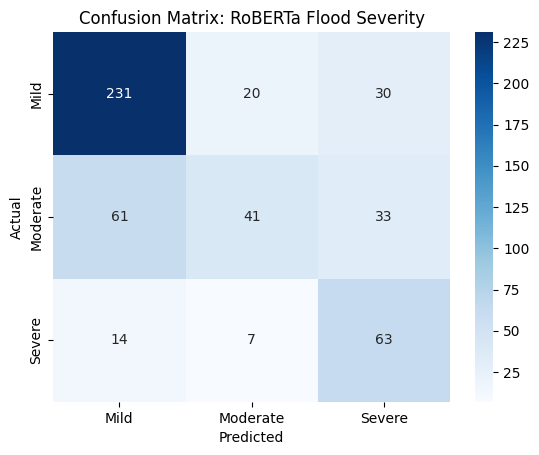

In [25]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds   = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Classification report
print(classification_report(all_labels, all_preds, target_names=severity_encoder.classes_))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=severity_encoder.classes_,
            yticklabels=severity_encoder.classes_,
            cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: RoBERTa Flood Severity')
plt.show()

## 17. Save Text Model and Extract Embeddings for GNN

In [26]:
# Save the fine-tuned model
model.save_pretrained('/content/roberta_flood_model')
tokenizer.save_pretrained('/content/roberta_flood_model')
print("Model saved!")

# Extract [CLS] embeddings from each split (needed as GNN node features later)
def get_embeddings(encodings):
    model.eval()
    embeddings = []
    with torch.no_grad():
        for i in range(0, len(encodings['input_ids']), 16):
            batch_ids  = encodings['input_ids'][i:i+16].to(device)
            batch_mask = encodings['attention_mask'][i:i+16].to(device)
            outputs    = model.roberta(input_ids=batch_ids, attention_mask=batch_mask)
            cls_emb    = outputs.last_hidden_state[:, 0, :]  # [CLS] token = 768-dim vector
            embeddings.append(cls_emb.cpu())
    return torch.cat(embeddings, dim=0)

train_embeddings = get_embeddings(train_enc)
val_embeddings   = get_embeddings(val_enc)
test_embeddings  = get_embeddings(test_enc)

torch.save(train_embeddings, '/content/train_text_embeddings.pt')
torch.save(val_embeddings,   '/content/val_text_embeddings.pt')
torch.save(test_embeddings,  '/content/test_text_embeddings.pt')

# Also key by tweet_id so the GNN step can align text embeddings with image embeddings
train_text_embeddings_by_tweet = dict(zip(train_df['tweet_id'], train_embeddings))
val_text_embeddings_by_tweet   = dict(zip(val_df['tweet_id'], val_embeddings))
test_text_embeddings_by_tweet  = dict(zip(test_df['tweet_id'], test_embeddings))

torch.save(train_text_embeddings_by_tweet, '/content/train_text_embeddings_by_tweet.pt')
torch.save(val_text_embeddings_by_tweet,   '/content/val_text_embeddings_by_tweet.pt')
torch.save(test_text_embeddings_by_tweet,  '/content/test_text_embeddings_by_tweet.pt')

print(f"Embeddings shape: {train_embeddings.shape}")  # expect (n_samples, 768)
print("Text embeddings saved (plain + tweet_id-keyed), ready for GNN!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved!
Embeddings shape: torch.Size([3997, 768])
Text embeddings saved (plain + tweet_id-keyed), ready for GNN!


## 18. Image Pipeline: Apply the Shared Split

In [27]:
train_img_df = image_label_df[image_label_df['tweet_id'].isin(train_tweets['tweet_id'])].copy()
val_img_df   = image_label_df[image_label_df['tweet_id'].isin(val_tweets['tweet_id'])].copy()
test_img_df  = image_label_df[image_label_df['tweet_id'].isin(test_tweets['tweet_id'])].copy()

train_img_df['label_enc'] = severity_encoder.transform(train_img_df['label'])
val_img_df['label_enc']   = severity_encoder.transform(val_img_df['label'])
test_img_df['label_enc']  = severity_encoder.transform(test_img_df['label'])

print(f"Images, Train: {len(train_img_df)}, Val: {len(val_img_df)}, Test: {len(test_img_df)}")
print(f"\nTrain image label distribution:\n{train_img_df['label'].value_counts()}")

class_weights_img = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_img_df['label_enc']),
    y=train_img_df['label_enc']
)
class_weights_tensor_img = torch.tensor(class_weights_img, dtype=torch.float).to(device)
print("\nImage class weights:", dict(zip(severity_encoder.classes_, class_weights_img)))

Images, Train: 2243, Val: 276, Test: 287

Train image label distribution:
label
Mild        886
Moderate    830
Severe      527
Name: count, dtype: int64

Image class weights: {np.str_('Mild'): np.float64(0.8438675696012039), np.str_('Moderate'): np.float64(0.9008032128514056), np.str_('Severe'): np.float64(1.4187223276407337)}


## 19. Image Preprocessing and Dataset Class

In [28]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

train_transform = transforms.Compose([
    transforms.Resize((299, 299)),  # InceptionV4 standard input size
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

eval_transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

class FloodImageDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['full_path']).convert('RGB')
        label = row['label_enc']

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

train_dataset_img = FloodImageDataset(train_img_df, transform=train_transform)
val_dataset_img   = FloodImageDataset(val_img_df, transform=eval_transform)
test_dataset_img  = FloodImageDataset(test_img_df, transform=eval_transform)

train_loader_img = DataLoader(train_dataset_img, batch_size=16, shuffle=True, num_workers=2)
val_loader_img   = DataLoader(val_dataset_img, batch_size=16, num_workers=2)
test_loader_img  = DataLoader(test_dataset_img, batch_size=16, num_workers=2)

print("Image datasets ready!")
print(f"Train batches: {len(train_loader_img)}, Val batches: {len(val_loader_img)}, Test batches: {len(test_loader_img)}")

Image datasets ready!
Train batches: 141, Val batches: 18, Test batches: 18


## 20. Load Pretrained InceptionV4 and Fine-Tune

In [29]:
import timm
import torch.nn as nn
from torch.optim import AdamW

model_img = timm.create_model('inception_v4', pretrained=True, num_classes=len(severity_encoder.classes_))
model_img.to(device)

optimizer_img = AdamW(model_img.parameters(), lr=1e-4)
loss_fn_img   = nn.CrossEntropyLoss(weight=class_weights_tensor_img)

print("InceptionV4 loaded with pretrained ImageNet weights, head replaced for 3 classes")

model.safetensors: reconstructing file:   0%|          |  0.00B /  171MB            

model.safetensors: downloading bytes:           |  0.00B            

InceptionV4 loaded with pretrained ImageNet weights, head replaced for 3 classes


## 21. Train with Early Stopping (Image)

In [30]:
EPOCHS = 20
best_val_loss = float('inf')
patience = 4
patience_counter = 0

for epoch in range(EPOCHS):
    # --- Training ---
    model_img.train()
    total_train_loss = 0
    for images, labels in train_loader_img:
        images, labels = images.to(device), labels.to(device)
        optimizer_img.zero_grad()
        outputs = model_img(images)
        loss = loss_fn_img(outputs, labels)
        loss.backward()
        optimizer_img.step()
        total_train_loss += loss.item()

    # --- Validation ---
    model_img.eval()
    total_val_loss = 0
    with torch.no_grad():
        for images, labels in val_loader_img:
            images, labels = images.to(device), labels.to(device)
            outputs = model_img(images)
            val_loss = loss_fn_img(outputs, labels)
            total_val_loss += val_loss.item()

    avg_train = total_train_loss / len(train_loader_img)
    avg_val   = total_val_loss / len(val_loader_img)
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f}")

    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save(model_img.state_dict(), '/content/best_inceptionv4_model.pt')
        print(f"  ✓ Best model saved at epoch {epoch+1}")
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"  No improvement ({patience_counter}/{patience})")
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

model_img.load_state_dict(torch.load('/content/best_inceptionv4_model.pt'))
print("\nBest InceptionV4 model loaded!")

Epoch 1/20 | Train Loss: 0.8894 | Val Loss: 0.9633
  ✓ Best model saved at epoch 1
Epoch 2/20 | Train Loss: 0.5151 | Val Loss: 1.0244
  No improvement (1/4)
Epoch 3/20 | Train Loss: 0.2860 | Val Loss: 1.2816
  No improvement (2/4)
Epoch 4/20 | Train Loss: 0.2291 | Val Loss: 1.4506
  No improvement (3/4)
Epoch 5/20 | Train Loss: 0.1922 | Val Loss: 1.5587
  No improvement (4/4)
Early stopping at epoch 5

Best InceptionV4 model loaded!


## 22. Evaluate Image Model on Test Set

              precision    recall  f1-score   support

        Mild       0.54      0.79      0.64       115
    Moderate       0.65      0.36      0.46       108
      Severe       0.59      0.53      0.56        64

    accuracy                           0.57       287
   macro avg       0.59      0.56      0.55       287
weighted avg       0.59      0.57      0.56       287



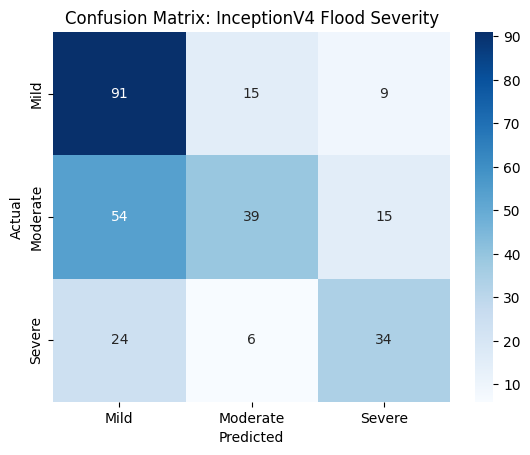

In [31]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model_img.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader_img:
        images, labels = images.to(device), labels.to(device)
        outputs = model_img(images)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=severity_encoder.classes_))

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=severity_encoder.classes_, yticklabels=severity_encoder.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: InceptionV4 Flood Severity')
plt.show()

## 23. Extract and Pool Image Embeddings for GNN

In [32]:
def get_image_embeddings(loader, model):
    model.eval()
    embeddings = []
    labels_list = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            features = model.forward_features(images)  # pre-classification-head features
            pooled = torch.nn.functional.adaptive_avg_pool2d(features, 1).squeeze(-1).squeeze(-1)
            embeddings.append(pooled.cpu())
            labels_list.append(labels)
    return torch.cat(embeddings, dim=0), torch.cat(labels_list, dim=0)

train_img_embeddings, train_img_labels = get_image_embeddings(train_loader_img, model_img)
val_img_embeddings, val_img_labels     = get_image_embeddings(val_loader_img, model_img)
test_img_embeddings, test_img_labels   = get_image_embeddings(test_loader_img, model_img)

print(f"Image embedding shape: {train_img_embeddings.shape}")  # expect (n_samples, 1536) for InceptionV4

torch.save(train_img_embeddings, '/content/train_image_embeddings.pt')
torch.save(val_img_embeddings,   '/content/val_image_embeddings.pt')
torch.save(test_img_embeddings,  '/content/test_image_embeddings.pt')

train_img_df[['tweet_id', 'label']].to_csv('/content/train_img_metadata.csv', index=False)
val_img_df[['tweet_id', 'label']].to_csv('/content/val_img_metadata.csv', index=False)
test_img_df[['tweet_id', 'label']].to_csv('/content/test_img_metadata.csv', index=False)

print("\nImage embeddings + metadata saved!")

Image embedding shape: torch.Size([2243, 1536])

Image embeddings + metadata saved!


In [33]:
def pool_embeddings_by_tweet(embeddings, img_df):
    """Average all image embeddings belonging to the same tweet_id"""
    img_df = img_df.reset_index(drop=True)
    pooled_rows = []

    for tweet_id, group in img_df.groupby('tweet_id'):
        idx = group.index.tolist()
        tweet_embedding = embeddings[idx].mean(dim=0)  # average across this tweet's images
        pooled_rows.append({
            'tweet_id': tweet_id,
            'label': group['label'].iloc[0],
            'embedding': tweet_embedding,
            'num_images': len(idx)
        })

    return pooled_rows

train_pooled = pool_embeddings_by_tweet(train_img_embeddings, train_img_df)
val_pooled   = pool_embeddings_by_tweet(val_img_embeddings, val_img_df)
test_pooled  = pool_embeddings_by_tweet(test_img_embeddings, test_img_df)

print(f"Train: {len(train_pooled)} tweet-level image embeddings (from {len(train_img_df)} images)")
print(f"Val: {len(val_pooled)} tweet-level image embeddings")
print(f"Test: {len(test_pooled)} tweet-level image embeddings")

train_img_embeddings_by_tweet = {r['tweet_id']: r['embedding'] for r in train_pooled}
val_img_embeddings_by_tweet   = {r['tweet_id']: r['embedding'] for r in val_pooled}
test_img_embeddings_by_tweet  = {r['tweet_id']: r['embedding'] for r in test_pooled}

torch.save(train_img_embeddings_by_tweet, '/content/train_image_embeddings_pooled.pt')
torch.save(val_img_embeddings_by_tweet,   '/content/val_image_embeddings_pooled.pt')
torch.save(test_img_embeddings_by_tweet,  '/content/test_image_embeddings_pooled.pt')

print("Pooled (per-tweet) image embeddings saved!")

Train: 855 tweet-level image embeddings (from 2243 images)
Val: 108 tweet-level image embeddings
Test: 110 tweet-level image embeddings
Pooled (per-tweet) image embeddings saved!


## 24. Shared Split Manifest

The single source of truth for GNN graph construction: every post in the shared split, which platform it's from, which partition it belongs to, and which modalities are available for it.

In [34]:
manifest = pd.concat([
    train_tweets.assign(split='train'),
    val_tweets.assign(split='val'),
    test_tweets.assign(split='test'),
], ignore_index=True)

manifest['platform']  = manifest['tweet_id'].str.split('_').str[0].map({'tw': 'twitter', 'fb': 'facebook'})
manifest['has_text']  = manifest['tweet_id'].isin(text_df['tweet_id'])
manifest['has_image'] = manifest['tweet_id'].isin(image_label_df['tweet_id'])

manifest.to_csv('/content/tweet_split_manifest.csv', index=False)

print(manifest['split'].value_counts())
print(f"\nBy platform:\n{manifest['platform'].value_counts()}")
print(f"\nPosts with text only:  {((manifest['has_text']) & (~manifest['has_image'])).sum()}")
print(f"Posts with image only: {((~manifest['has_text']) & (manifest['has_image'])).sum()}")
print(f"Posts with both:       {((manifest['has_text']) & (manifest['has_image'])).sum()}")
print("\nManifest saved to /content/tweet_split_manifest.csv. Use it to align text and image embeddings by tweet_id when building the GNN graph.")

split
train    4050
val       507
test      507
Name: count, dtype: int64

By platform:
platform
facebook    4335
twitter      729
Name: count, dtype: int64

Posts with text only:  3990
Posts with image only: 66
Posts with both:       1007

Manifest saved to /content/tweet_split_manifest.csv. Use it to align text and image embeddings by tweet_id when building the GNN graph.


## 25. Geocode Posts to City and Barangay

Gazetteer-based matching, not full NER, since the target area is a small, enumerable list (Pasig's 30 barangays, Marikina's 16, and Manila's 16 traditional districts, since its actual barangays are just numbers nobody writes in a post). Every post in `text_df` gets tagged, but this is additive: it does not filter or change the split above, since the classifiers still train on the full corpus. Only the GNN and map step below use the geocoded subset, per the train broad, map narrow plan.

Three confidence tiers, worst to best: a weak/common barangay name alone (e.g. "San Jose", which exists all over the Philippines), a distinctive barangay name alone (e.g. "Kapitolyo"), or an explicit city name. Only `city_name` and `distinctive_barangay` are treated as in-scope below; `weak_barangay`-only matches are kept in the data but excluded from the graph, the same precision tradeoff discussed when this gazetteer was first prototyped.

In [35]:
CITY_TERMS = {
    'Pasig': ['Pasig', 'Pasig City'],
    'Marikina': ['Marikina', 'Marikina City'],
    'Manila': ['Manila', 'Manila City'],
}

DISTINCTIVE_BARANGAYS = {
    'Pasig': ['Bagong Ilog', 'Bagong Katipunan', 'Kalawaan', 'Kapasigan', 'Kapitolyo', 'Malinao',
              'Manggahan', 'Maybunga', 'Oranbo', 'Palatiw', 'Pinagbuhatan', 'Pineda', 'Sagad',
              'Santolan', 'Sumilang', 'Ugong', 'Caniogan'],
    'Marikina': ['Barangka', 'Concepcion Uno', 'Concepcion Dos', 'Jesus Dela Pena', 'Kalumpang',
                 'Marikina Heights', 'Nangka', 'Tumana', 'Industrial Valley', 'Malanday', 'Tanong'],
    'Manila': ['Binondo', 'Ermita', 'Intramuros', 'Malate', 'Pandacan', 'Quiapo', 'Sampaloc',
               'Santa Mesa', 'Tondo', 'Paco'],
}

WEAK_BARANGAYS = {
    'Pasig': ['Bambang', 'Buting', 'Dela Paz', 'San Antonio', 'San Joaquin', 'San Jose',
              'San Miguel', 'San Nicolas', 'Santa Cruz', 'Santa Lucia', 'Santa Rosa', 'Santo Tomas',
              'Rosario'],
    'Marikina': ['San Roque', 'Santa Elena', 'Santo Nino', 'Parang', 'Fortune'],
    'Manila': ['San Andres', 'San Miguel', 'San Nicolas', 'Santa Ana', 'Port Area'],
}

def _compile_terms(terms):
    return [re.compile(r'\b' + re.escape(t) + r'\b', re.IGNORECASE) for t in terms]

_CITY_RE = {c: _compile_terms(t) for c, t in CITY_TERMS.items()}
_DIST_RE = {c: list(zip(DISTINCTIVE_BARANGAYS[c], _compile_terms(DISTINCTIVE_BARANGAYS[c]))) for c in CITY_TERMS}
_WEAK_RE = {c: list(zip(WEAK_BARANGAYS[c], _compile_terms(WEAK_BARANGAYS[c]))) for c in CITY_TERMS}

def geocode_text(text):
    if not isinstance(text, str) or not text:
        return pd.Series({'matched_city': None, 'matched_barangay': None, 'geo_confidence': 'none'})

    best_city, best_barangay, best_rank = None, None, 0
    for city in CITY_TERMS:
        city_rank = 3 if any(p.search(text) for p in _CITY_RE[city]) else 0

        barangay_name, barangay_rank = None, 0
        for name, pattern in _DIST_RE[city]:
            if pattern.search(text):
                barangay_name, barangay_rank = name, 2
                break
        if barangay_rank == 0:
            for name, pattern in _WEAK_RE[city]:
                if pattern.search(text):
                    barangay_name, barangay_rank = name, 1
                    break

        city_total_rank = max(city_rank, barangay_rank)
        if city_total_rank > best_rank:
            best_rank, best_city, best_barangay = city_total_rank, city, barangay_name

    tier = {0: 'none', 1: 'weak_barangay', 2: 'distinctive_barangay', 3: 'city_name'}[best_rank]
    return pd.Series({'matched_city': best_city, 'matched_barangay': best_barangay, 'geo_confidence': tier})

geo_cols = text_df['text'].apply(geocode_text)
text_df = pd.concat([text_df.reset_index(drop=True), geo_cols.reset_index(drop=True)], axis=1)

print(text_df['geo_confidence'].value_counts())

IN_SCOPE_TIERS = {'city_name', 'distinctive_barangay'}
in_scope_tweet_ids = set(text_df.loc[text_df['geo_confidence'].isin(IN_SCOPE_TIERS), 'tweet_id'])
print(f"\nIn-scope (geocoded) posts: {len(in_scope_tweet_ids)} / {len(text_df)}")
print(f"\nBy city (in-scope only):\n{text_df[text_df['tweet_id'].isin(in_scope_tweet_ids)]['matched_city'].value_counts()}")

geo_confidence
none                    3388
city_name               1342
weak_barangay            162
distinctive_barangay     105
Name: count, dtype: int64

In-scope (geocoded) posts: 1447 / 4997

By city (in-scope only):
matched_city
Manila      830
Marikina    431
Pasig       186
Name: count, dtype: int64


## 26. Build the GNN Graph

Nodes are in-scope posts with a text embedding (every in-scope post should have one, since the split above covers all of `text_df`). A node's features are its RoBERTa CLS embedding concatenated with its pooled Inception-v4 embedding, zero-padded plus a has-image flag when no photo was matched, so a text-only node isn't silently penalized for a missing modality it was never expected to have.

Edges follow the spatio-temporal design settled on earlier: two posts are connected if they fall in the same spatial unit (barangay when known, otherwise the coarser city-level bucket) and within a `TIME_WINDOW_DAYS` window of each other, so an old, unrelated post can't corroborate a current one just because they happened to be geocoded to the same place.

In [36]:
TEXT_DIM = 768
IMAGE_DIM = 1536
TIME_WINDOW_DAYS = 3

all_text_embeddings_by_tweet = {}
all_text_embeddings_by_tweet.update(train_text_embeddings_by_tweet)
all_text_embeddings_by_tweet.update(val_text_embeddings_by_tweet)
all_text_embeddings_by_tweet.update(test_text_embeddings_by_tweet)

all_image_embeddings_by_tweet = {}
all_image_embeddings_by_tweet.update(train_img_embeddings_by_tweet)
all_image_embeddings_by_tweet.update(val_img_embeddings_by_tweet)
all_image_embeddings_by_tweet.update(test_img_embeddings_by_tweet)

node_tweet_ids = sorted(in_scope_tweet_ids & set(all_text_embeddings_by_tweet.keys()))
print(f"GNN nodes (in-scope + has a text embedding): {len(node_tweet_ids)}")

node_features, has_image_flags = [], []
for tid in node_tweet_ids:
    text_emb = all_text_embeddings_by_tweet[tid]
    if tid in all_image_embeddings_by_tweet:
        image_emb = all_image_embeddings_by_tweet[tid]
        has_image = 1.0
    else:
        image_emb = torch.zeros(IMAGE_DIM)
        has_image = 0.0
    node_features.append(torch.cat([text_emb, image_emb, torch.tensor([has_image])]))
    has_image_flags.append(has_image)

x = torch.stack(node_features)
print(f"Node feature matrix shape: {tuple(x.shape)}")
print(f"Nodes with a matched image: {int(sum(has_image_flags))} / {len(node_tweet_ids)}")

tweet_meta = text_df.drop_duplicates(subset=['tweet_id']).set_index('tweet_id')
node_city = [tweet_meta.loc[tid, 'matched_city'] for tid in node_tweet_ids]
node_barangay = [tweet_meta.loc[tid, 'matched_barangay'] for tid in node_tweet_ids]
node_label = [tweet_meta.loc[tid, 'label'] for tid in node_tweet_ids]
node_time = pd.to_datetime([tweet_meta.loc[tid, 'createdAt'] for tid in node_tweet_ids], errors='coerce', utc=True)

y = torch.tensor(severity_encoder.transform(node_label), dtype=torch.long)

train_id_set = set(train_tweets['tweet_id'])
val_id_set   = set(val_tweets['tweet_id'])
test_id_set  = set(test_tweets['tweet_id'])

train_mask = torch.tensor([tid in train_id_set for tid in node_tweet_ids])
val_mask   = torch.tensor([tid in val_id_set for tid in node_tweet_ids])
test_mask  = torch.tensor([tid in test_id_set for tid in node_tweet_ids])

print(f"\nGraph nodes, Train: {train_mask.sum().item()}, Val: {val_mask.sum().item()}, Test: {test_mask.sum().item()}")

GNN nodes (in-scope + has a text embedding): 1447
Node feature matrix shape: (1447, 2305)
Nodes with a matched image: 259 / 1447

Graph nodes, Train: 1151, Val: 147, Test: 149


In [37]:
from collections import defaultdict
from itertools import combinations

# Spatial key: barangay when known, else a coarser (city, None) bucket. O(n^2) within each
# group, fine at this node count; revisit if a single city-level bucket grows into the thousands.
spatial_key = [
    (node_city[i], node_barangay[i]) if node_barangay[i] else (node_city[i], None)
    for i in range(len(node_tweet_ids))
]

groups = defaultdict(list)
for i, key in enumerate(spatial_key):
    groups[key].append(i)

edge_src, edge_dst = [], []
for key, idxs in groups.items():
    if len(idxs) < 2:
        continue
    for i, j in combinations(idxs, 2):
        t_i, t_j = node_time[i], node_time[j]
        if pd.isna(t_i) or pd.isna(t_j):
            continue
        if abs((t_i - t_j).days) <= TIME_WINDOW_DAYS:
            edge_src += [i, j]
            edge_dst += [j, i]

edge_index = torch.tensor([edge_src, edge_dst], dtype=torch.long) if edge_src else torch.zeros((2, 0), dtype=torch.long)
print(f"Total directed edges (both directions counted): {edge_index.shape[1]}")
if len(node_tweet_ids):
    print(f"Average degree: {edge_index.shape[1] / len(node_tweet_ids):.2f}")

Total directed edges (both directions counted): 28992
Average degree: 20.04


## 27. Define and Train the GNN

If the install below fails or `SAGEConv` errors on import, PyG occasionally needs its CUDA-matched wheel instead of the plain package. In that case run: `!pip install torch_geometric -f https://data.pyg.org/whl/torch-$(python -c "import torch; print(torch.__version__)").html` and retry. This can't be verified without actually running it in Colab, so treat it as the first thing to check if this section breaks.

In [38]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.5 MB/s eta 0:00:00


In [39]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv

class FloodGNN(nn.Module):
    def __init__(self, in_dim, hidden_dim, num_classes):
        super().__init__()
        self.conv1 = SAGEConv(in_dim, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, hidden_dim)
        self.classifier = nn.Linear(hidden_dim, num_classes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x, edge_index):
        h = F.relu(self.conv1(x, edge_index))
        h = self.dropout(h)
        h = F.relu(self.conv2(h, edge_index))
        h = self.dropout(h)
        return self.classifier(h)

graph_data = Data(x=x, edge_index=edge_index, y=y,
                   train_mask=train_mask, val_mask=val_mask, test_mask=test_mask)
graph_data = graph_data.to(device)

gnn_model = FloodGNN(in_dim=x.shape[1], hidden_dim=256, num_classes=len(severity_encoder.classes_)).to(device)

gnn_class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y[train_mask].numpy()),
    y=y[train_mask].numpy()
)
gnn_class_weights_tensor = torch.tensor(gnn_class_weights, dtype=torch.float).to(device)

gnn_optimizer = torch.optim.Adam(gnn_model.parameters(), lr=0.01, weight_decay=5e-4)
gnn_loss_fn = nn.CrossEntropyLoss(weight=gnn_class_weights_tensor)

EPOCHS_GNN = 200
best_val_loss = float('inf')
patience = 20
patience_counter = 0

for epoch in range(EPOCHS_GNN):
    gnn_model.train()
    gnn_optimizer.zero_grad()
    out = gnn_model(graph_data.x, graph_data.edge_index)
    loss = gnn_loss_fn(out[graph_data.train_mask], graph_data.y[graph_data.train_mask])
    loss.backward()
    gnn_optimizer.step()

    gnn_model.eval()
    with torch.no_grad():
        out = gnn_model(graph_data.x, graph_data.edge_index)
        val_loss = gnn_loss_fn(out[graph_data.val_mask], graph_data.y[graph_data.val_mask])

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS_GNN} | Train Loss: {loss.item():.4f} | Val Loss: {val_loss.item():.4f}")

    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        torch.save(gnn_model.state_dict(), '/content/best_gnn_model.pt')
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

gnn_model.load_state_dict(torch.load('/content/best_gnn_model.pt'))
print("\nBest GNN model loaded, ready for evaluation!")

Epoch 10/200 | Train Loss: 0.8873 | Val Loss: 0.8472
Epoch 20/200 | Train Loss: 0.7061 | Val Loss: 0.6895
Epoch 30/200 | Train Loss: 0.5718 | Val Loss: 0.7094
Early stopping at epoch 39

Best GNN model loaded, ready for evaluation!


## 28. Evaluate the GNN

              precision    recall  f1-score   support

        Mild       0.63      0.74      0.68        58
    Moderate       0.64      0.43      0.51        54
      Severe       0.62      0.76      0.68        37

    accuracy                           0.63       149
   macro avg       0.63      0.64      0.63       149
weighted avg       0.63      0.63      0.62       149



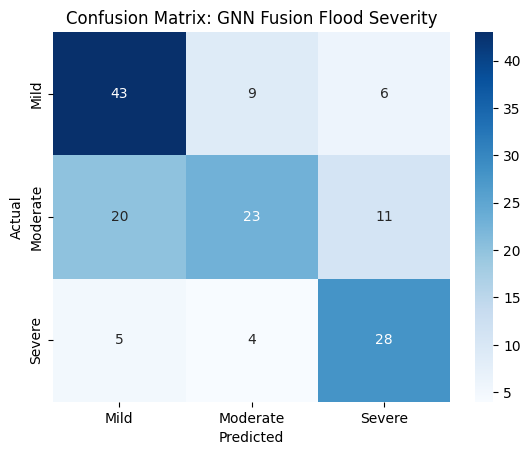

In [40]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

gnn_model.eval()
with torch.no_grad():
    out = gnn_model(graph_data.x, graph_data.edge_index)
    all_gnn_preds = torch.argmax(out, dim=1)

test_preds  = all_gnn_preds[graph_data.test_mask].cpu().numpy()
test_labels = graph_data.y[graph_data.test_mask].cpu().numpy()

print(classification_report(test_labels, test_preds, target_names=severity_encoder.classes_))

cm = confusion_matrix(test_labels, test_preds)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=severity_encoder.classes_,
            yticklabels=severity_encoder.classes_,
            cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: GNN Fusion Flood Severity')
plt.show()

## 29. Generate the Barangay Severity Map Data

The actual deliverable: every in-scope node's predicted severity, aggregated to the dominant (mode) class per barangay, ready to replace the placeholder tile colors in the Baha Watch mockup.

In [41]:
node_df = pd.DataFrame({
    'tweet_id': node_tweet_ids,
    'matched_city': node_city,
    'matched_barangay': node_barangay,
    'true_label': severity_encoder.inverse_transform(y.numpy()),
    'predicted_label': severity_encoder.inverse_transform(all_gnn_preds.cpu().numpy()),
})
node_df['map_unit'] = node_df['matched_barangay'].fillna('(city-level, no barangay)')

def _mode_label(s):
    m = s.mode()
    return m.iloc[0] if not m.empty else None

barangay_summary = (
    node_df.groupby(['matched_city', 'map_unit'])
    .agg(dominant_severity=('predicted_label', _mode_label), post_count=('predicted_label', 'size'))
    .reset_index()
    .sort_values(['matched_city', 'post_count'], ascending=[True, False])
)

print(barangay_summary.to_string(index=False))

barangay_summary.to_csv('/content/barangay_severity_map.csv', index=False)
node_df.to_csv('/content/gnn_node_predictions.csv', index=False)
print("\nSaved barangay_severity_map.csv and gnn_node_predictions.csv")

matched_city                  map_unit dominant_severity  post_count
      Manila (city-level, no barangay)              Mild         741
      Manila                  Sampaloc            Severe          42
      Manila                     Tondo              Mild          17
      Manila                    Ermita              Mild           8
      Manila                Intramuros              Mild           7
      Manila                    Malate              Mild           3
      Manila                    Quiapo              Mild           3
      Manila                San Miguel              Mild           2
      Manila                Santa Mesa              Mild           2
      Manila                   Binondo            Severe           1
      Manila                      Paco              Mild           1
      Manila                  Pandacan              Mild           1
      Manila                San Andres          Moderate           1
      Manila               San Nic